In [1]:
%pylab widget
%load_ext autoreload
%autoreload 2

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
# Read the mhd file from data
from fastcat import patient_data
import fastcat as fc

In [5]:
nrrd_file = '/media/jericho/T7/dfci_laptop_backup/Documents/christian_patient_data/BRAIN/2_Stereo_CNS_Scan.nrrd'
phantom2 = patient_data.patient_phantom(nrrd_file, reload=True, sim_num=14)

[2024-03-28 11:00:49,342] {patient_data.py:63} INFO - Reloading phantom
[2024-03-28 11:00:49,343] {patient_data.py:111} INFO - Found existing directory. Using mhd file 2_Stereo_CNS_Scan_phantom.mhd
[2024-03-28 11:00:49,343] {patient_data.py:113} INFO - Reloading phantom from pickle file 2_Stereo_CNS_Scan
[2024-03-28 11:00:49,678] {patient_data.py:141} INFO - Phantom loaded from pickle file fastmc_1e08_3angles.pkl
[2024-03-28 11:00:49,678] {patient_data.py:146} INFO - Loading ggems files
[2024-03-28 11:00:49,679] {patient_data.py:174} INFO - Using the first detector layer ggems files
[2024-03-28 11:00:49,750] {patient_data.py:208} INFO - ggems files loaded
[2024-03-28 11:00:49,751] {patient_data.py:209} INFO -     Scatter files:
[2024-03-28 11:00:49,751] {patient_data.py:212} INFO -         /home/jericho/Software/fastcat/fastcat/data/user_phantoms/2_Stereo_CNS_Scan/fastmc_output_14/fastmc_0.00-scatter.mhd
[2024-03-28 11:00:49,751] {patient_data.py:212} INFO -         /home/jericho/Softw

In [25]:
phantom2.run_fastcat(1e10,3)

[2024-03-28 09:54:44,219] {patient_data.py:322} INFO - Making a list of angles
[2024-03-28 09:54:44,220] {patient_data.py:350} INFO - Detector matching specifications: CsI-784-micrometer


[2024-03-28 09:54:44,222] {ggems_simulate.py:227} INFO - Initializing filter /home/jericho/Software/fastcat/fastcat/data/bowties/full_fan_alt.dat
[2024-03-28 09:54:45,840] {ggems_simulate.py:626} INFO - Running Simulations
[2024-03-28 09:54:45,841] {ggems_simulate.py:654} INFO -     Simulating 10 keV
[2024-03-28 09:54:46,440] {ggems_simulate.py:654} INFO -     Simulating 20 keV
[2024-03-28 09:54:47,039] {ggems_simulate.py:654} INFO -     Simulating 30 keV
[2024-03-28 09:54:47,614] {ggems_simulate.py:654} INFO -     Simulating 40 keV
[2024-03-28 09:54:48,187] {ggems_simulate.py:654} INFO -     Simulating 50 keV
[2024-03-28 09:54:48,771] {ggems_simulate.py:654} INFO -     Simulating 60 keV
[2024-03-28 09:54:49,359] {ggems_simulate.py:654} INFO -     Simulating 70 keV
[2024-03-28 09:54:49,931] {ggems_simulate.py:654} INFO -     Simulating 80 keV
[2024-03-28 09:54:50,504] {ggems_simulate.py:654} INFO -     Simulating 90 keV
[2024-03-28 09:54:51,087] {ggems_simulate.py:654} INFO -     Simul

In [7]:
phantom2.correct_intensity(ml=False)

AttributeError: 'patient_phantom' object has no attribute 'intensity'

AttributeError: 'patient_phantom' object has no attribute 'intensity'

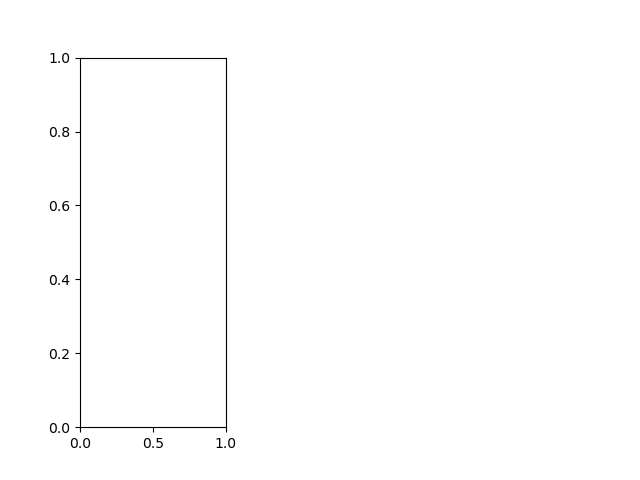

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(131)

from scipy.ndimage import gaussian_filter

filt_sigma = 1
int1 = gaussian_filter(phantom2.ggems_primary_projections[2],filt_sigma)
int2 = gaussian_filter(phantom2.intensity[0],filt_sigma)

proj1 = -np.log(int1/np.rot90(phantom2.ggems_flood))
proj2 = -np.log(int2/phantom2.flood_field)
# gaussian blur the projections using scipy ndimage 

crop = 20

plt.imshow(int1)
plt.axis('off')
plt.title(f'GGEMS $\sigma$={filt_sigma}')
plt.subplot(132)
plt.imshow(proj2[crop:-crop,crop:-crop],cmap='turbo',vmin=0,vmax=4)
plt.axis('off')
plt.title(f'Fastcat $\sigma$={filt_sigma}')

# Plot the difference 
plt.subplot(133)
diff_1 = 100*(proj1[crop:-crop,crop:-crop]-proj2[crop:-crop,crop:-crop])/4
plt.axis('off')
plt.title('Difference')
plt.imshow(diff_1,cmap='bwr',vmin=-5,vmax=5)
plt.colorbar(orientation='horizontal')

# plot the mean of the difference image along both axes
plt.figure()
plt.plot(np.mean(diff_1,axis=0))
plt.plot(np.mean(diff_1,axis=1))

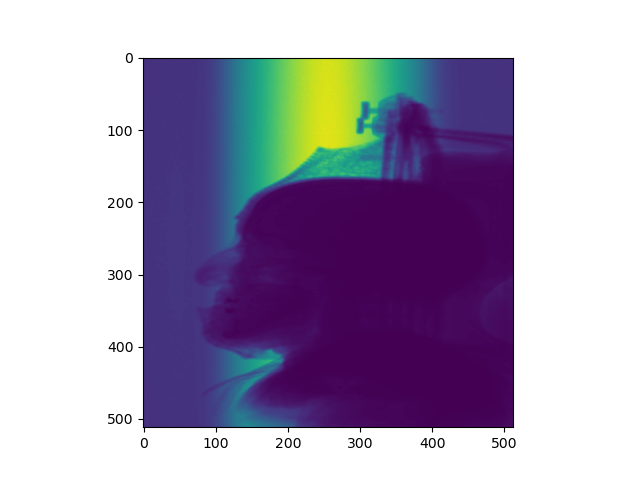

In [8]:
import matplotlib.pyplot as plt
import mpl_interactions as pli

plt.figure()
pli.hyperslicer(phantom.intensity)

In [ ]:
# Read the mhd file from data
from fastcat.ggems_scatter import generate_ggems_bash_script
import fastcat as fc
import numpy as np
from fastcat.fastmc_scatter import write_fastmc_xml_file, run_fastmc_files, write_fastmc_flood_field_xml_file

out_file = '/home/jericho/1-Workspace/1-jupyter_notebooks/2-fastcat_ggems/test'

# 1024 * 768 is the real resolution of the detector

range_file = '/home/jericho/1-Workspace/fastcat_gate/Catphan604_Range.txt'
mhd_file = '/home/jericho/1-Workspace/fastcat_gate/Catphan604.mhd'
material_file = '/home/jericho/1-Workspace/fastcat_gate/Materials.txt'
# material_file = '/home/jericho/1-Workspace/fastcat_ggems/custom_materials_gate.txt'
spectrum_file = '/home/jericho/1-Workspace/1-jupyter_notebooks/4-preliminary_fastmc_projections/spectrum_120kVp_2.75mmAl_0.89mmTi.dat'
# spectrum_file = '/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/data/120kV_2.5mmAl.dat'
# range_file = '/home/jericho/1-Workspace/fastcat_gate/Catphan604_Range.txt'
bowtie_file = '/home/jericho/Downloads/firefox-downloads/full_fan_alt.dat'

# nparticles = 1000000  # 000
out = 'out'

s = fc.Spectrum()
s.load(spectrum_file=spectrum_file)
spectrum = spectrum_file
s_max = s.x.max()

Catphan604_phantom = fc.utils.get_phantom_from_mhd(
    mhd_file, range_file, material_file)

Catphan604_phantom.detector_thickness = 0.6
Catphan604_phantom.detector_thickness2 = 0.8
Catphan604_phantom.detector_material = 'CsI'
Catphan604_phantom.nparticles_per_angle = int(1e10)  # 00 #00
Catphan604_phantom.bowtie_file = bowtie_file
Catphan604_phantom.spectrum_file = spectrum_file
Catphan604_phantom.material_file = material_file
Catphan604_phantom.mhd_file = mhd_file
Catphan604_phantom.range_file = range_file

file_base = '/home/jericho/1-Workspace/1-jupyter_notebooks/4-preliminary_fastmc_projections/test/'
angles = np.linspace(0, np.pi*2, 10, endpoint=False)
fnames = []

Catphan604_phantom.sim_angles = angles
out_dir = '/home/jericho/1-Workspace/1-jupyter_notebooks/4-preliminary_fastmc_projections/out_dir'
sim_dir = '/home/jericho/1-Workspace/1-jupyter_notebooks/4-preliminary_fastmc_projections/sim_dir'

write_fastmc_flood_field_xml_file(phantom=Catphan604_phantom, out_dir=out_dir, sim_dir=sim_dir,
                                  file_name=file_base, half_fan=False)

write_fastmc_xml_file(phantom=Catphan604_phantom, out_dir=out_dir, sim_dir=sim_dir,
                      file_name=file_base, half_fan=False)

run_fastmc_files(
    lib_path='/home/jericho/Downloads/FastMC_Jan_05/FastMC_install/bin/FastMC', sim_dir=sim_dir)